# Diffusion Models from Scratch


Chúng ta sẽ xem xét 2 phần:

Phần 1: Mô hình đơn giản
- Quá trình thêm nhiễu vào ảnh (The Corruption Process)
-Xây dựng mô hình khử nhiễu (UNet, skip connection, xây dựng Mini Unet)
- Huấn luện mô hình và sinh ảnh bằng mô hình đã học (Sampling)

Phần 2: Phần nâng cao
- So sánh với Diffusion Model chuẩn (DDPM)
- Unet trong DDPM
- Noise schedule
- Timestep Conditioning

Phần 3: So sánh chất lượng sinh ảnh
- DDIM với DDPM
- Determistic với Stochastic

## Setup and Imports:
(Khai báo thư viện)




In [1]:
%pip install -q diffusers

In [2]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


## The Data

Sử dụng bộ data MNIST

Bộ dữ liệu MNIST là một tập hợp các chữ số viết tay phổ biến, thường được sử dụng để huấn luyện các hệ thống xử lý hình ảnh. Nó bao gồm 60.000 mẫu đào tạo và 10.000 mẫu thử nghiệm. Mỗi mẫu là một hình ảnh thang độ xám 28x28 pixel của một chữ số viết tay từ 0 đến 9.

In [3]:
dataset = torchvision.datasets.MNIST(root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.57MB/s]


In [4]:
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
# DataLoader: là một hàm xử lý dữ liệu đầu vào --> Chia batch, xáo trộn dữ liệu
# batch_size=8: Số ảnh được gộp chung lại để xử lý trong một lần tính toán
#shuffle = True: Xáo trộn ngẫu nhiên toàn bộ dữ liệu ở mỗi đầu chu kỳ huấn luyện (epoch)

Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([1, 2, 1, 4, 7, 1, 1, 4])


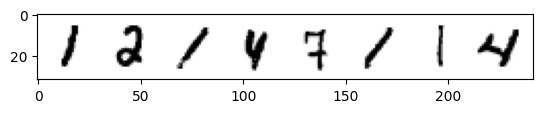

In [5]:
x, y = next(iter(train_dataloader))
print('Input shape:', x.shape) #x là tensor đầu vào gồm 8 ảnh đen trắng kích thước 28*28
print('Labels:', y) #y là nhãn
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');

Kích thước đầu vào là (8,1,28,28) ->(Batch size, Channels, Height, Width)


Mỗi bức ảnh là ảnh xám (binary) kích thức 28*28 pixel với giá trị là từ 0 ->1


** Phần 1: Mô hình đơn giản**
## Quá trình làm nhiễu

---

Chúng ta có lẽ muốn một cách dễ dàng để kiểm soát mức độ làm nhiễu. Vậy thì sao nếu chúng ta đưa vào một tham số cho `amount` (lượng) nhiễu cần thêm, và sau đó chúng ta thực hiện:

`noise = torch.rand_like(x)`

`noisy_x = (1 - amount) * x + amount * noise`

Nếu `amount = 0`, chúng ta nhận lại đầu vào mà không có bất kỳ thay đổi nào. Nếu `amount` tăng lên đến `1`, chúng ta nhận lại hoàn toàn nhiễu mà không còn dấu vết nào của đầu vào `x`. Bằng cách trộn đầu vào với nhiễu theo cách này, chúng ta giữ đầu ra trong cùng một phạm vi giá trị (từ 0 đến 1).


In [6]:
def corrupt(x, amount): # Hàm corrupt trả về x với lượng (amount) nhiễu (random) được thêm vào
  """Corrupt the input `x` by mixing it with noise according to `amount`"""
  noise = torch.rand_like(x) # tạo ra nhiễu random có kích thước giống x
  amount = amount.view(-1, 1, 1, 1) # Resize lại kích thước của 'amount' để từ kích thước (8,) sang (8,1,1,1)
  # --> Để thực hiện các phép toán với x
  print('Kích thước của amount bên TRONG hàm corrupt (sau khi view):', amount.shape)
  return x*(1-amount) + noise*amount

And looking at the results visually to see that it works as expected:

Kích thước của amount ban đầu (ngoài hàm): torch.Size([8])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([8, 1, 1, 1])


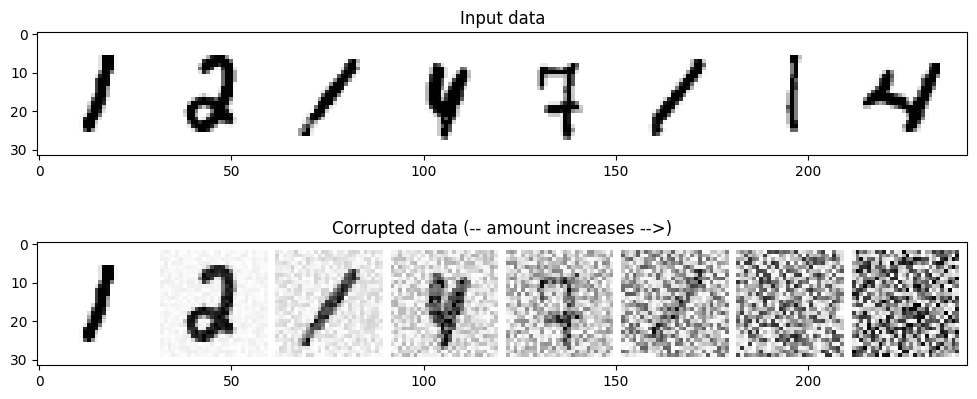

In [7]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap='Greys')

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Tạo ra một dãy số cách đều nhau từ 0 đến 1 với số lượng phần tử là steps.
# -->Khi bạn truyền amount này vào hàm corrupt, nó sẽ gán mức nhiễu tăng dần cho các ảnh:
# ảnh đầu tiên có nhiễu = 0 (giữ nguyên), ảnh cuối cùng có nhiễu = 1 (biến thành nhiễu hoàn toàn).
print('Kích thước của amount ban đầu (ngoài hàm):', amount.shape)

# Khi gọi corrupt, lệnh print bên trong hàm sẽ hiển thị kích thước đã được view
noised_x = corrupt(x, amount) # x đã được làm nhiễu

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap='Greys');
plt.show()

## Mô hình (The Model)

Chúng ta cần một mô hình nhận đầu vào là ảnh nhiễu 28px và trả về kết quả dự đoán có cùng kích thước. Một lựa chọn phổ biến cho việc này là kiến trúc có tên là **UNet**. [Ban đầu được phát minh cho các tác vụ phân vùng ảnh (segmentation) trong y tế](https://arxiv.org/abs/1505.04597), UNet bao gồm một "nhánh co hẹp" (constricting path) giúp nén dữ liệu xuống và một "nhánh mở rộng" (expanding path) giúp khôi phục dữ liệu về kích thước ban đầu (tương tự như một autoencoder). Tuy nhiên, nó còn có các "kết nối tắt" (skip connections) cho phép thông tin và gradient truyền qua trực tiếp giữa các cấp độ khác nhau.

Một số mô hình UNet sử dụng các khối (block) phức tạp ở mỗi giai đoạn, nhưng trong bản demo đơn giản này, chúng ta sẽ xây dựng một ví dụ tối giản: nhận vào ảnh một kênh (ảnh xám), đi qua ba lớp tích chập (convolutional layers) ở nhánh xuống (down_layers) và ba lớp ở nhánh lên (up_layers), kèm theo các kết nối tắt giữa chúng. Chúng ta sẽ sử dụng `max pooling` để giảm kích thước (downsampling) và `nn.Upsample` để tăng kích thước (upsampling) thay vì sử dụng các lớp có thể học được như các mô hình UNet phức tạp hơn.

Dưới đây là sơ đồ kiến trúc sơ bộ hiển thị số lượng kênh (channels) ở đầu ra của mỗi lớp:

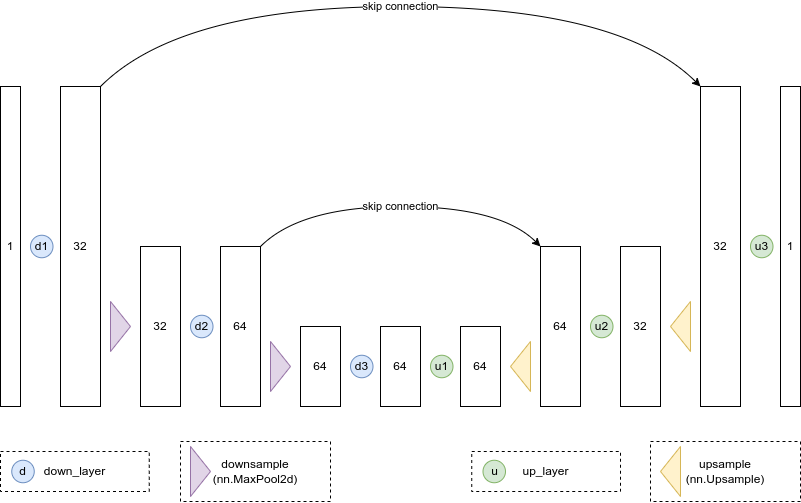

### Giải thích về Kích thước Đầu vào và Đầu ra của UNet:

Nhìn vào sơ đồ trên, bạn có thể thấy sự thay đổi của dữ liệu qua hai nhánh:

1.  **Nhánh xuống (Down path - Nhánh co hẹp):**
    *   **Kích thước ảnh (Spatial size):** Giảm dần thông qua các lớp `MaxPool2d`. Từ **28x28** -> **14x14** -> **7x7**. Việc giảm kích thước này giúp mô hình học được các đặc trưng ở quy mô lớn hơn (global features).
    *   **Số lượng kênh (Channels):** Tăng dần để mô hình có thể học được nhiều đặc trưng phức tạp hơn. Trong code của bạn là từ **1 (ảnh xám)** -> **32** -> **64**.

2.  **Nhánh lên (Up path - Nhánh mở rộng):**
    *   **Kích thước ảnh:** Tăng dần trở lại nhờ `nn.Upsample`. Từ **7x7** -> **14x14** -> **28x28**. Mục tiêu là khôi phục lại độ phân giải ban đầu của ảnh.
    *   **Kết nối tắt (Skip Connections):** Đây là các mũi tên ngang. Đầu ra của nhánh xuống được cộng (hoặc nối) trực tiếp vào nhánh lên có cùng kích thước. Điều này giúp mô hình không bị mất các chi tiết nhỏ (pixel-level) đã bị mất trong quá trình nén ở nhánh xuống.

3.  **Kết quả cuối cùng:**
    *   Mô hình trả về một Tensor có kích thước **(Batch, 1, 28, 28)**.
    *   Nó hoàn toàn khớp với kích thước ảnh gốc, giúp chúng ta so sánh trực tiếp ảnh dự đoán với ảnh sạch để tính toán lỗi (Loss).


Xây dựng miniUnet:

In [8]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation."""
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList([
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])

        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
        ])

        self.act = nn.SiLU()
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        # Nhánh xuống (Down path)
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))
            if i < 2:
              h.append(x)
              x = self.downscale(x)

        # Nhánh lên (Up path)
        for i, l in enumerate(self.up_layers):
            if i > 0:
              x = self.upscale(x)
              x += h.pop() # Skip connection
            x = self.act(l(x))
        return x

Ví dụ về kernel size và padding
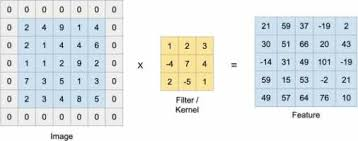

Hàm SiLU activation:
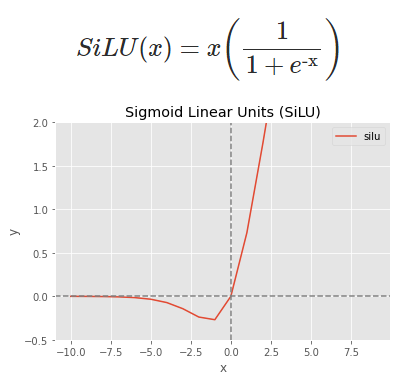

Maxpool2d 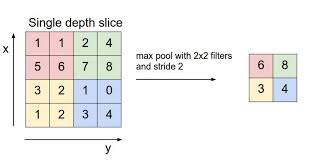

Kiểm tra đầu ra có giống đầu vào khi qua mạng Unet không

In [9]:
net = BasicUNet()
x = torch.rand(8, 1, 28, 28)
net(x).shape

torch.Size([8, 1, 28, 28])

Mạng này có hơn 300,000 parameters:

In [10]:
sum([p.numel() for p in net.parameters()])

309057

## Training the network


We can now have a go at training the network.
- Get a batch of data
- Corrupt it by random amounts
- Feed it through the model
- Compare the model predictions with the clean images to calculate our loss
- Update the model's parameters accordingly.


Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt

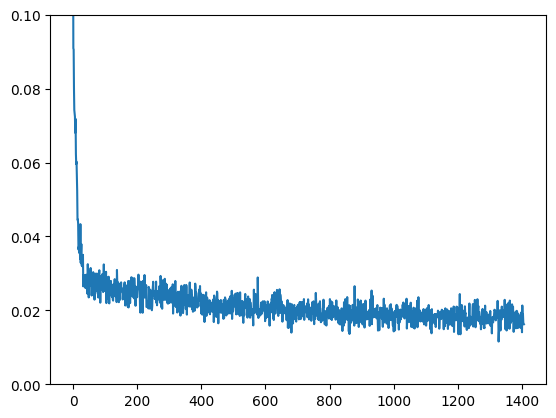

In [11]:
# Dataloader (you can mess with batch size)
batch_size = 128
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 3

# Create the network
net = BasicUNet()
net.to(device)

# Our loss function --> So sánh dự đoán với đầu vào có khớp không
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount) # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x)

        # Calculate the loss
        loss = loss_fn(pred, x) # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1);

Visualizing dự đoán nhiễu của mô hình

Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([8, 1, 1, 1])


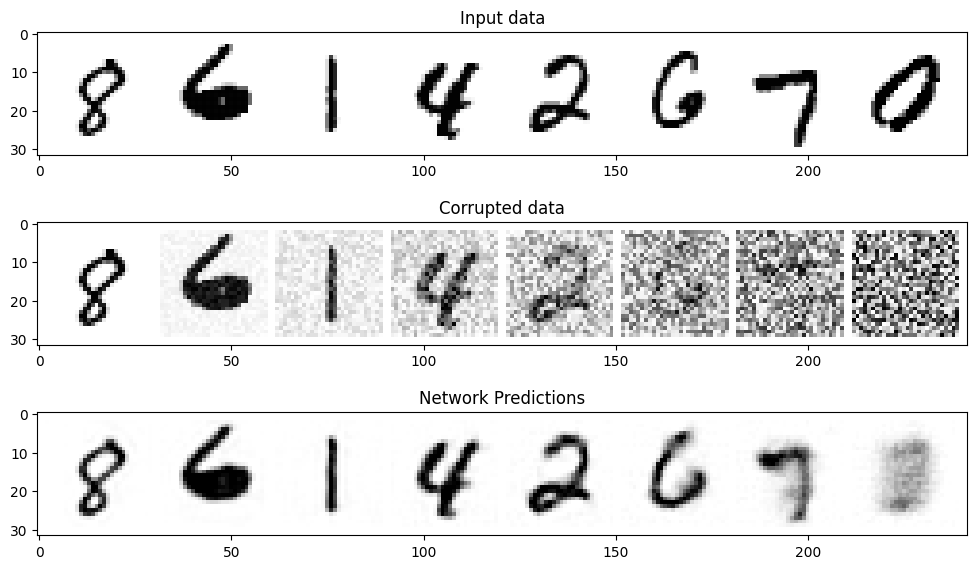

In [12]:

# Lấy 8 ảnh để trực quan
x, y = next(iter(train_dataloader))
x = x[:8]

# Thêm lượng nhiễu (lượng nhiễu đưọc tăng từ trái qua phải)
amount = torch.linspace(0, 1, x.shape[0])
noised_x = corrupt(x, amount)

# Get the model predictions
with torch.no_grad():
  preds = net(noised_x.to(device)).detach().cpu()

# Plot
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0].clip(0, 1), cmap='Greys')  # vẽ x
axs[1].set_title('Corrupted data')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0].clip(0, 1), cmap='Greys') # Vẽ noised_x
axs[2].set_title('Network Predictions')
axs[2].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap='Greys'); # Vẽ preds: dự đoán của mạng đối với x

Nhận xét:
Lượng nhiễu amount nhỏ hơn 1 mô hình có thể nhận ra được nhưng khi nhiễu =1 nó cho thấy mô hình bị nhận nhầm

## Lấy mẫu (Sampling)

Nếu dự đoán của chúng ta ở mức nhiễu cao không được tốt, làm thế nào để chúng ta tạo ra hình ảnh?

Nếu chúng ta bắt đầu từ nhiễu ngẫu nhiên, xem xét dự đoán của mô hình nhưng sau đó chỉ tiến một bước nhỏ về phía dự đoán đó - ví dụ, khoảng 20% quãng đường. Bây giờ chúng ta có một hình ảnh rất nhiễu nhưng có lẽ đã bắt đầu xuất hiện một chút cấu trúc thấp thoáng, chúng ta có thể đưa hình ảnh này vào mô hình để nhận một dự đoán mới. Hy vọng là dự đoán mới này sẽ tốt hơn một chút so với dự đoán đầu tiên (vì điểm bắt đầu của chúng ta đã bớt nhiễu hơn một chút) và vì thế chúng ta có thể thực hiện một bước nhỏ khác với dự đoán mới và tốt hơn này.

Lặp lại quá trình này một vài lần và (nếu mọi việc suôn sẻ) chúng ta sẽ có được một hình ảnh! Dưới đây là quy trình đó được minh họa qua 5 bước, trực quan hóa đầu vào của mô hình (bên trái) và ảnh khử nhiễu được dự đoán (bên phải) ở mỗi giai đoạn. Lưu ý rằng ngay cả khi mô hình dự đoán ảnh đã khử nhiễu ngay tại bước 1, chúng ta cũng chỉ di chuyển một phần quãng đường tới đó. Qua từng bước, các cấu trúc xuất hiện và được tinh chỉnh cho đến khi chúng ta có được kết quả cuối cùng.

**Chiến thuật: Chia quá trình khử nhiễu ra làm 5 bước**

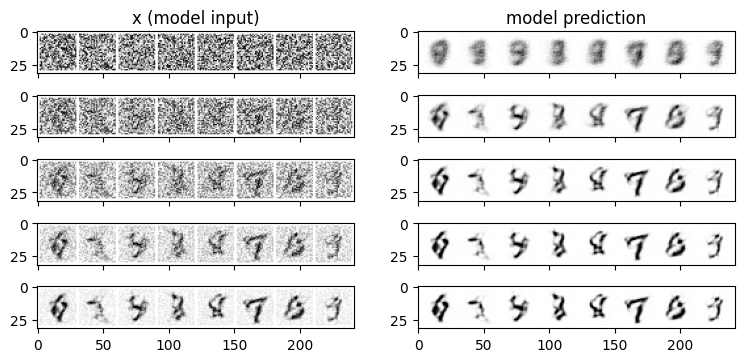

In [13]:
n_steps = 5
x = torch.rand(8, 1, 28, 28).to(device) # Tạo một ảnh nhiễu random
step_history = [x.detach().cpu()]
pred_output_history = []

for i in range(n_steps): # Chia nhỏ nhiều lần khử nhiễu
    with torch.no_grad():
        pred = net(x) # Dự đoán x được khử nhiễu
    pred_output_history.append(pred.detach().cpu()) # Lưu trữ các đầu ra của mạng để vẽ
    mix_factor = 1/(n_steps - i)
    # (hệ số pha trộn) đại diện cho mức độ tin tưởng vào bức ảnh do mô hình dự đoán (pred) ở bước hiện tại i
    x = x*(1-mix_factor) + pred*mix_factor # Kết hợp của lượng ảnh(nhiễu)cũ được giữ lại + Lượng ảnh rõ nét (dự đoán) được bơm thêm vào)
    step_history.append(x.detach().cpu()) # Store step for plotting

fig, axs = plt.subplots(n_steps, 2, figsize=(9, 4), sharex=True)
axs[0,0].set_title('x (model input)')
axs[0,1].set_title('model prediction')
for i in range(n_steps):
    axs[i, 0].imshow(torchvision.utils.make_grid(step_history[i])[0].clip(0, 1), cmap='Greys')
    axs[i, 1].imshow(torchvision.utils.make_grid(pred_output_history[i])[0].clip(0, 1), cmap='Greys')

Ta có thể viết lại dưới dạng toán học cho dễ nhìn, gọi $\alpha$ là mix_factor:$$x_{mới} = x_{cũ} \cdot (1 - \alpha) + pred \cdot \alpha$$Hãy xẻ đôi công thức này ra để thấy ý nghĩa vật lý của nó:

Phần 1: $x_{cũ} \cdot (1 - \alpha)$: Đây là lượng ảnh (nhiễu) cũ được giữ lại. Nếu $\alpha$ nhỏ (ví dụ 0.25), thì $(1 - 0.25) = 0.75$. Nghĩa là ta giữ lại tới 75% trạng thái cũ.

Phần 2: $pred \cdot \alpha$: Đây là lượng ảnh rõ nét (dự đoán) được bơm thêm vào. Nếu $\alpha = 0.25$, ta lấy 25% bức ảnh rõ nét đắp vào.

### So sánh: Khử nhiễu 1 bước vs. Khử nhiễu nhiều bước

Tại sao chúng ta không để mô hình dự đoán và lấy kết quả luôn trong 1 lần? Hãy cùng xem sự khác biệt khi áp dụng trên cùng một dữ liệu nhiễu đầu vào.

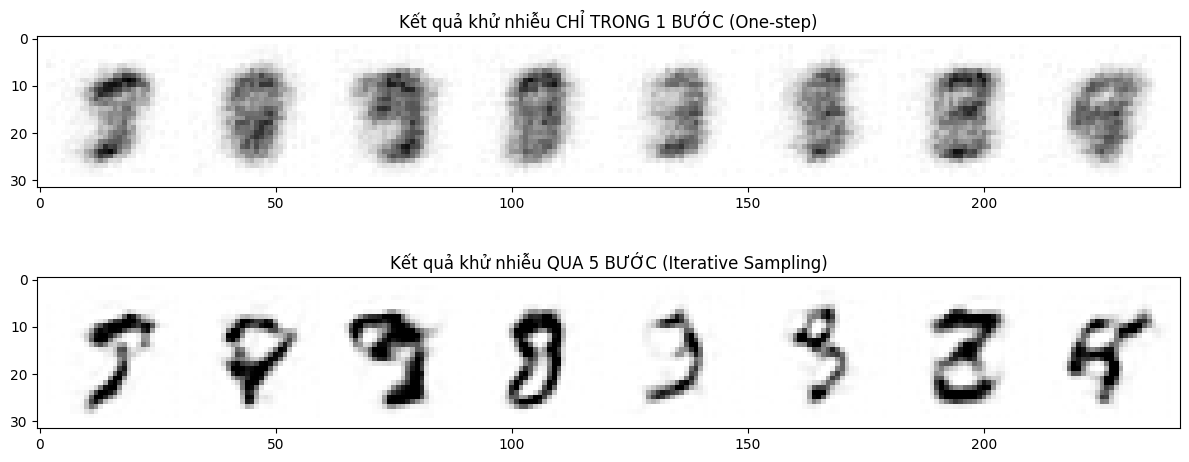

In [14]:
n_steps = 5
# 1. Tạo cùng một mẫu nhiễu cho cả 2 phương pháp
seed_noise = torch.rand(8, 1, 28, 28).to(device)

# --- PHƯƠNG PHÁP 1 BƯỚC (One-step) ---
with torch.no_grad():
    one_step_result = net(seed_noise)

# --- PHƯƠNG PHÁP NHIỀU BƯỚC (Multi-step) ---
x_multi = seed_noise.clone()
for i in range(n_steps):
    with torch.no_grad():
        pred = net(x_multi)
    mix_factor = 1/(n_steps - i)
    x_multi = x_multi*(1-mix_factor) + pred*mix_factor

# --- TRỰC QUAN HÓA SO SÁNH ---
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Kết quả khử nhiễu CHỈ TRONG 1 BƯỚC (One-step)')
axs[0].imshow(torchvision.utils.make_grid(one_step_result.cpu())[0].clip(0, 1), cmap='Greys')

axs[1].set_title(f'Kết quả khử nhiễu QUA {n_steps} BƯỚC (Iterative Sampling)')
axs[1].imshow(torchvision.utils.make_grid(x_multi.cpu())[0].clip(0, 1), cmap='Greys')

plt.tight_layout()
plt.show()

**Chúng ta có thể chia quá trình thành nhiều bước khử nhiễu (sampling steps) hơn và dự đoán rằng có ảnh tốt hơn theo cách này**

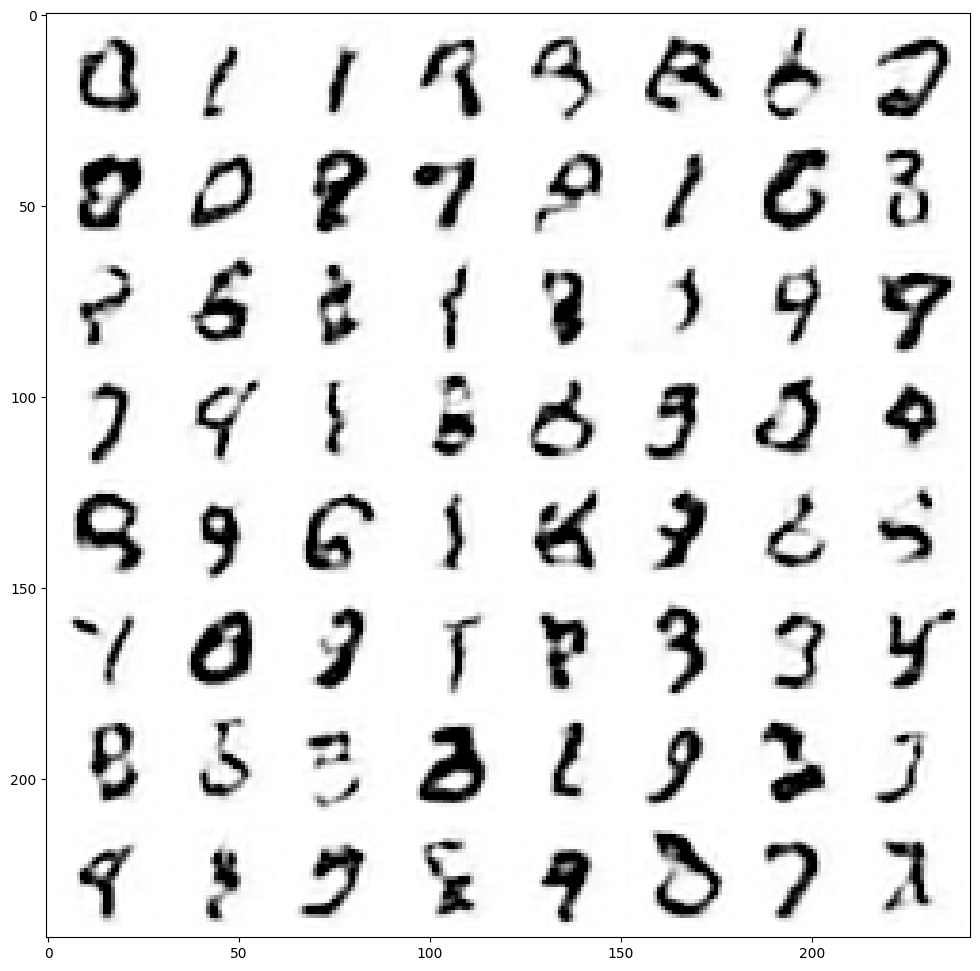

In [15]:
#@markdown Showing more results, using 40 sampling steps
n_steps = 40
x = torch.rand(64, 1, 28, 28).to(device)
for i in range(n_steps):
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) # Starting high going low
  with torch.no_grad():
    pred = net(x)
  mix_factor = 1/(n_steps - i)
  x = x*(1-mix_factor) + pred*mix_factor
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')

**Phần 2: Phần nâng cao**
## Comparison To DDPM


Khác với BasicUnet ở phần này chúng ta sẽ xem xét kỹ UNet2DModel:

-Quá trình làm nhiễu được xử lý khác.

-Mục tiêu huấn luyện khác, bao gồm việc dự đoán nhiễu thay vì hình ảnh đã được khử nhiễu.

-Mô hình được điều kiện hóa dựa trên lượng nhiễu hiện có thông qua điều kiện hóa theo bước thời gian (timestep conditioning), trong đó t được truyền dưới dạng một đối số bổ sung cho phương thức forward.


### The UNet


Mô hình UNet2DModel của diffusers có một số cải tiến so với BasicUNet cơ bản của chúng ta ở trên:

- GroupNorm áp dụng chuẩn hóa nhóm cho đầu vào của mỗi khối.
Các lớp Dropout để huấn luyện mượt mà hơn.

- Nhiều lớp resnet trên mỗi khối (nếu layers_per_block không được đặt thành 1).

- Attention (thường chỉ được sử dụng ở các khối độ phân giải thấp hơn).

- Điều kiện hóa theo timestep.

-Các khối lấy mẫu xuống (Downsampling) và lấy mẫu lên (Upsampling) với các tham số có thể học được.


In [17]:
model = UNet2DModel(
    sample_size=28,           # Kích thước ảnh đầu vào
    in_channels=1,            # Số chiều đầu vào của ảnh đầu vào (Ảnh binary)
    out_channels=1,           # Số chiều đầu ra của ảnh đầu vào (Ảnh binary)
    layers_per_block=2,       # thay vì chỉ dùng 1 lớp Conv2d, mô hình sẽ dùng 2 lớp ResNet liên tiếp.
    # -->Việc này giúp mạng học được các đặc trưng phức tạp và sâu sắc hơn rất nhiều so với BasicUNet.
    block_out_channels=(32, 64, 64),
    # Quy định số lượng filter (kênh đặc trưng) ở 3 cấp độ của mạng chữ U.
    #   Cấp độ 1: 32 kênh
    #   Cấp độ 2: 64 kênh
    #   Cấp độ 3 (Đáy chữ U): 64 kênh
    #   --> Kích thước tương đương BasicUnet
    down_block_types=(
        "DownBlock2D",        # a regular ResNet downsampling block
        "AttnDownBlock2D",    # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    # Chiều đi xuống mạng UNet
    # Mạng có 3 cấp độ (tương ứng với 3 con số ở block_out_channels), nên bạn phải định nghĩa 3 loại khối ở đây:
    # "DownBlock2D": Ở cấp độ 1 (ảnh 28x28 -> 14x14), sử dụng khối ResNet thu nhỏ bình thường.
    #               Nó tập trung trích xuất các đường nét, góc cạnh cơ bản.
    # "AttnDownBlock2D": Ở cấp độ 2 và 3, mô hình sử dụng khối kết hợp giữa ResNet và Self-Attention.
    #               Vì lúc này kích thước ảnh đã bị thu nhỏ (chỉ còn 14x14 và 7x7),
    #               việc áp dụng Attention sẽ không quá tốn RAM, nhưng lại giúp mô hình có "tầm nhìn toàn cục" (global context)
    #               — nó biết được điểm ảnh ở góc trái có liên quan gì đến điểm ảnh ở góc phải, thay vì chỉ nhìn thiển cận xung quanh như Conv2d.
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",      # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",          # a regular ResNet upsampling block
      ),
)

# Nguyên tắc của UNet là nhánh đi lên phải đối xứng như một tấm gương với nhánh đi xuống.
# Bạn đi xuống bằng: Thường -> Attention -> Attention.
# Thì bạn phải đi lên bằng: Attention -> Attention -> Thường.
# Đó là lý do up_block_types bắt đầu bằng 2 khối "AttnUpBlock2D" để xử lý các độ phân giải thấp ở đáy chữ U,
# và kết thúc bằng một khối "UpBlock2D" bình thường khi ảnh được phóng to ra 28x28 ở bước cuối.
print(model)

UNet2DModel(
  (conv_in): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=32, out_features=128, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 32, eps=1e-05, affine=True)
          (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(32, 32, ker

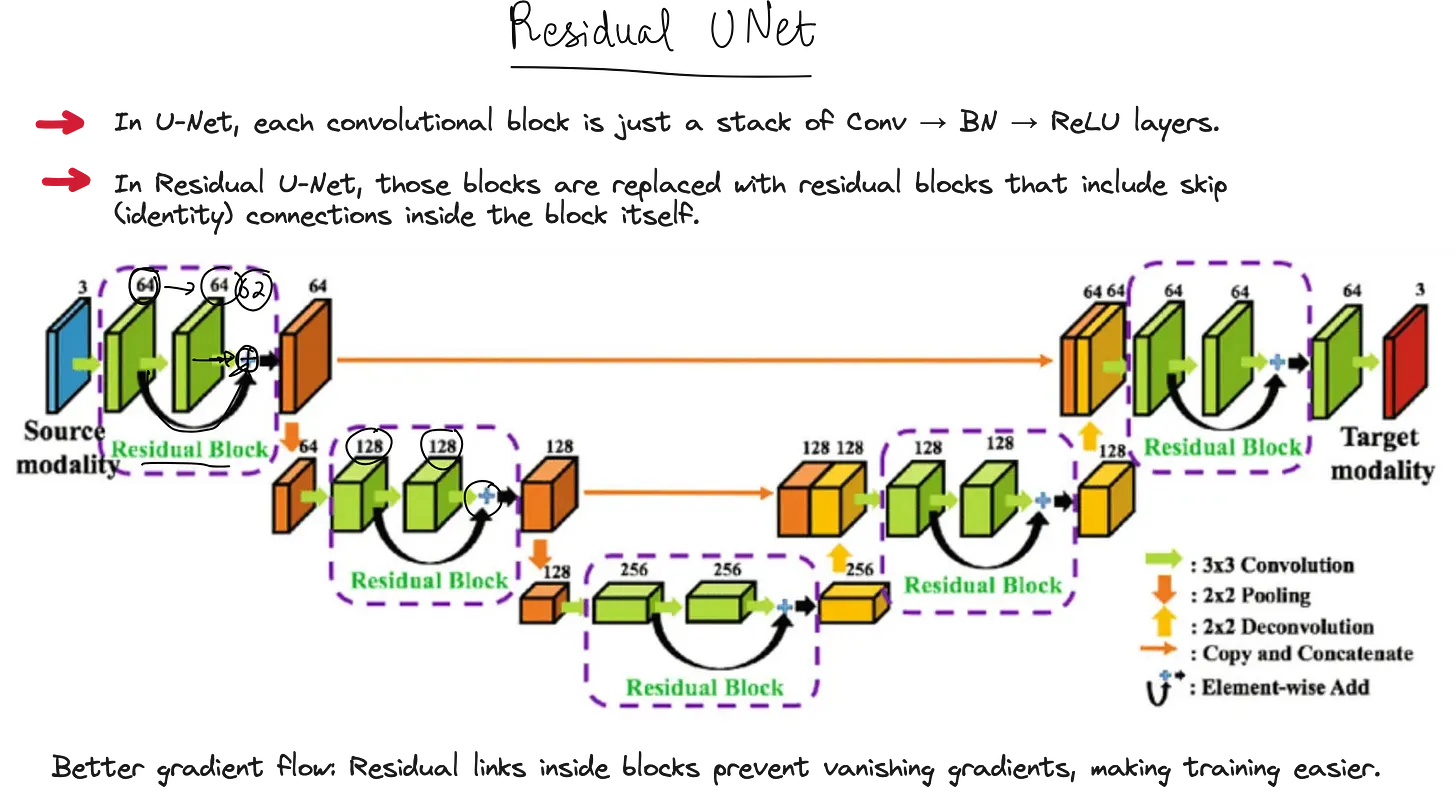

In [ ]:
sum([p.numel() for p in model.parameters()]) # 1.7M vs the ~309k parameters of the BasicUNet

Nhận xét: Mạng UNet2D có nhiều tham số hơn mạng BasicUnet

## Thử UNet2D thay cho BasicUNet

Ở đây chúng ta cần truyền đầu vào là cả x và timestep cho mô hình (nhưng đặt t=0 để cho thấy rằng nó hoạt động mà không cần điều kiện hóa theo bước thời gian)


Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt (sau khi view): torch.Size([128, 1, 1, 1])
Kích thước của amount bên TRONG hàm corrupt

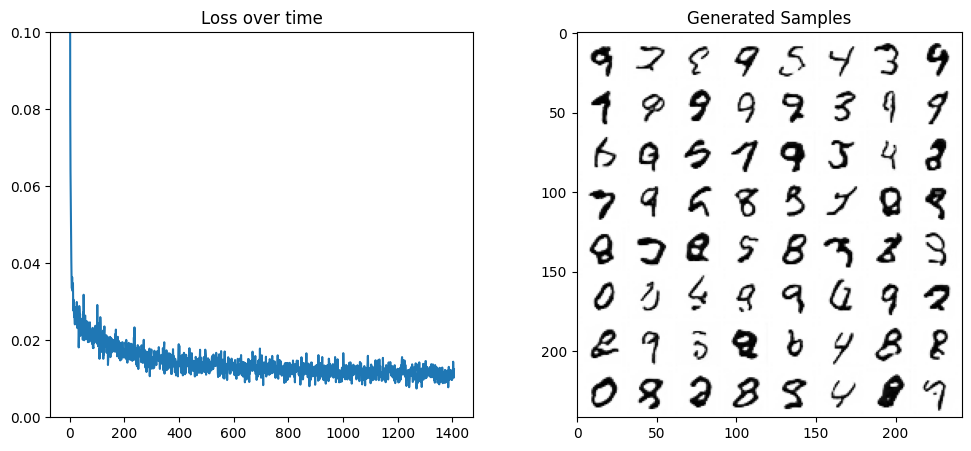

In [18]:


# Dataloader (you can mess with batch size)
batch_size = 128
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 3

# Create the network
net = UNet2DModel(
    sample_size=28,  # the target image resolution
    in_channels=1,  # the number of input channels, 3 for RGB images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 64),  # Roughly matching our basic unet example
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",   # a regular ResNet upsampling block
      ),
) #<<<
net.to(device)

# Our loss finction
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device) # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount) # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x, 0).sample #<<< Using timestep 0 always, adding .sample

        # Calculate the loss
        loss = loss_fn(pred, x) # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader):])/len(train_dataloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# Plot losses and some samples
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Losses
axs[0].plot(losses)
axs[0].set_ylim(0, 0.1)
axs[0].set_title('Loss over time')

# Samples
n_steps = 40
x = torch.rand(64, 1, 28, 28).to(device)
for i in range(n_steps):
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) # Starting high going low
  with torch.no_grad():
    pred = net(x, 0).sample
  mix_factor = 1/(n_steps - i)
  x = x*(1-mix_factor) + pred*mix_factor

axs[1].imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap='Greys')
axs[1].set_title('Generated Samples');

### Quá trình làm nhiễu

Bài báo DDPM mô tả một quá trình làm nhiễu thêm một lượng nhỏ nhiễu vào mỗi 'bước thời gian' (timestep). Với $x_{t-1}$ ở một bước thời gian nào đó, chúng ta có thể nhận được phiên bản tiếp theo (hơi nhiễu hơn một chút) $x_t$ với:

$q(\mathbf{x}_t \vert \mathbf{x}_{t-1}) = \mathcal{N}(\mathbf{x}_t; \sqrt{1 - \beta_t} \mathbf{x}_{t-1}, \beta_t\mathbf{I}) \quad
q(\mathbf{x}_{1:T} \vert \mathbf{x}_0) = \prod^T_{t=1} q(\mathbf{x}_t \vert \mathbf{x}_{t-1})$

Tức là, chúng ta lấy $x_{t-1}$, điều chỉnh tỷ lệ của nó bằng $\sqrt{1 - \beta_t}$ và thêm nhiễu được điều chỉnh tỷ lệ bằng $\beta_t$. Giá trị $\beta$ này được định nghĩa cho mỗi $t$ theo một lịch trình nhất định và xác định lượng nhiễu được thêm vào mỗi bước thời gian. Bây giờ, chúng ta không nhất thiết phải thực hiện phép toán này 500 lần để có được $x_{500}$ nên chúng ta có một công thức khác để có được $x_t$ cho bất kỳ $t$ nào khi biết $x_0$:

$q(\mathbf{x}_t \vert \mathbf{x}_0) = \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, \sqrt{(1 - \bar{\alpha}_t)} \mathbf{I})$ trong đó $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$ và $\alpha_i = 1-\beta_i$

Chúng ta có thể vẽ $\sqrt{\bar{\alpha}_t}$ (được gọi là `sqrt_alpha_prod`) và $\sqrt{(1 - \bar{\alpha}_t)}$ (được gọi là `sqrt_one_minus_alpha_prod`) để xem đầu vào ($x$) và nhiễu được điều chỉnh tỷ lệ và trộn lẫn như thế nào qua các bước thời gian khác nhau:

## Thêm nhiễu DDPMScheduler


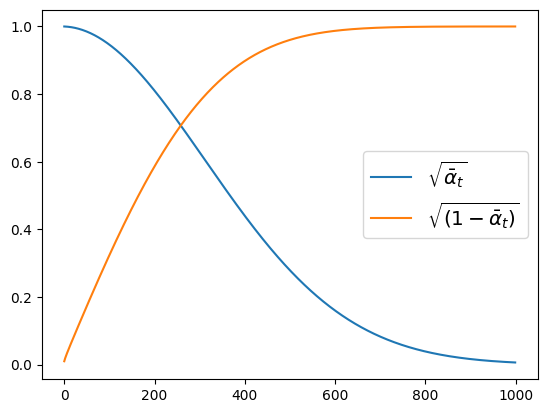

In [21]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
#quá trình khuếch tán (từ ảnh sạch đến nhiễu hoàn toàn) được chia thành 1000 bước thời gian.
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large");

Ban đầu, $x$ nhiễu chủ yếu là $x$ ($\text{sqrt_alpha_prod} \approx 1$), nhưng theo thời gian, đóng góp của $x$ giảm dần và thành phần nhiễu tăng lên. Không giống như cách trộn tuyến tính $x$ và nhiễu theo 'amount' của chúng ta, cách này trở nên nhiễu tương đối nhanh chóng. Chúng ta có thể trực quan hóa điều này trên một số dữ liệu:

## Trực quan hóa quá trình thêm nhiễu với mỗi timestep khác nhau

X shape torch.Size([8, 1, 28, 28])
Noisy X shape torch.Size([8, 1, 28, 28])


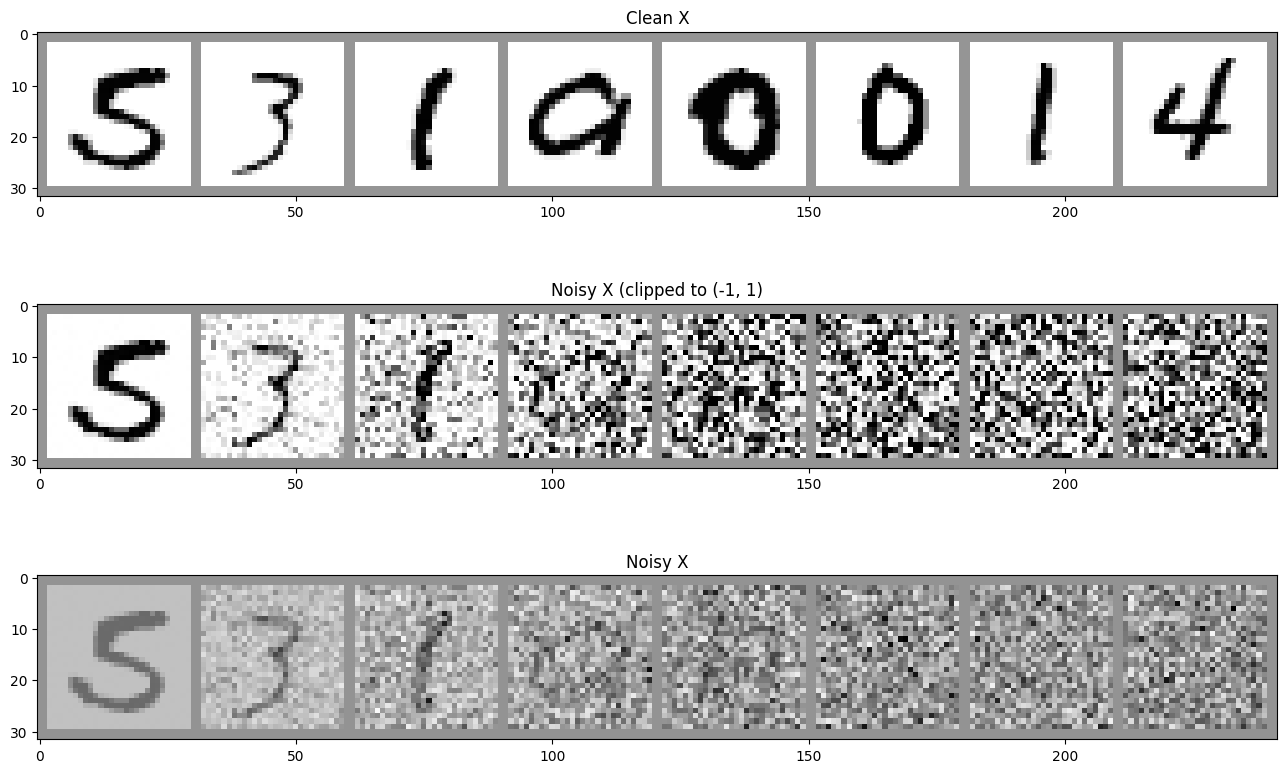

In [22]:
# Noise a batch of images to view the effect
fig, axs = plt.subplots(3, 1, figsize=(16, 10))
xb, yb = next(iter(train_dataloader)) #Lấy một batch dữ liệu từ train_dataloader.
# xb là tensor chứa các hình ảnh, yb là các nhãn tương ứng.
xb = xb.to(device)[:8]
xb = xb * 2. - 1. # Map to (-1, 1)
"""
Bước quan trọng này chuẩn hóa dữ liệu hình ảnh từ khoảng [0, 1] sang khoảng [-1, 1].
Đây là một phương pháp chuẩn hóa phổ biến trong các mô hình diffusion,
--> đặc biệt khi sử dụng nhiễu Gaussian có phân phối chuẩn tắc (mean 0, variance 1).
"""
print('X shape', xb.shape)

# Show clean inputs
axs[0].imshow(torchvision.utils.make_grid(xb[:8])[0].detach().cpu(), cmap='Greys')
axs[0].set_title('Clean X')

# Add noise with scheduler
timesteps = torch.linspace(0, 999, 8).long().to(device)
"""
Tạo một tensor chứa 8 bước thời gian khác nhau, trải đều từ 0 đến 999 (tổng số 1000 bước thời gian được định nghĩa trong DDPMScheduler).
Mỗi hình ảnh trong batch sẽ được làm nhiễu với một mức độ nhiễu tương ứng với một bước thời gian khác nhau.
"""
noise = torch.randn_like(xb)
#Tạo một tensor nhiễu ngẫu nhiên có cùng kích thước và phân phối (Gaussian) với xb. randn tạo ra nhiễu từ phân phối chuẩn tắc (mean 0, variance 1),
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
#Đây là bước cốt lõi. Hàm add_noise của DDPMScheduler áp dụng quy trình làm nhiễu DDPM lên hình ảnh sạch xb, sử dụng nhiễu noise và các timesteps đã cho
print('Noisy X shape', noisy_xb.shape)

# Show noisy version (with and without clipping)
axs[1].imshow(torchvision.utils.make_grid(noisy_xb[:8])[0].detach().cpu().clip(-1, 1),  cmap='Greys')
axs[1].set_title('Noisy X (clipped to (-1, 1)')
axs[2].imshow(torchvision.utils.make_grid(noisy_xb[:8])[0].detach().cpu(),  cmap='Greys')
axs[2].set_title('Noisy X');

### 1. So sánh DDPM và DDIM
Chúng ta sẽ sử dụng cùng một mô hình đã huấn luyện nhưng dùng 2 bộ Scheduler khác nhau. DDIM thường cho kết quả sắc nét hơn khi số lượng bước lấy mẫu (sampling steps) ít.

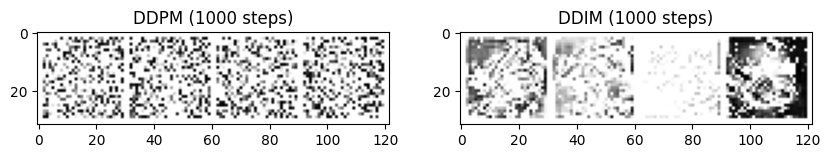

In [25]:
from diffusers import DDIMScheduler, DDPMScheduler

# Thiết lập số bước lấy mẫu ít (ví dụ 50 bước)
n_steps = 1000
ddim_scheduler = DDIMScheduler(num_train_timesteps=1000)
ddpm_scheduler = DDPMScheduler(num_train_timesteps=1000)

ddim_scheduler.set_timesteps(n_steps)
ddpm_scheduler.set_timesteps(n_steps)

# Bắt đầu từ cùng một nhiễu ngẫu nhiên ban đầu
random_input = torch.randn(4, 1, 28, 28).to(device)

def sample_with_scheduler(scheduler, start_x):
    x = start_x.clone()
    for t in scheduler.timesteps:
        with torch.no_grad():
            # Giả lập input cho model (DDPMScheduler thường nhận noise prediction)
            residual = net(x, t).sample
        x = scheduler.step(residual, t, x).prev_sample
    return x

ddim_results = sample_with_scheduler(ddim_scheduler, random_input)
ddpm_results = sample_with_scheduler(ddpm_scheduler, random_input)

# Hiển thị kết quả
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(torchvision.utils.make_grid(ddpm_results.cpu())[0].clip(0, 1), cmap='Greys')
axs[0].set_title(f'DDPM ({n_steps} steps)')
axs[1].imshow(torchvision.utils.make_grid(ddim_results.cpu())[0].clip(0, 1), cmap='Greys')
axs[1].set_title(f'DDIM ({n_steps} steps)')
plt.show()

### 2. So sánh Deterministic vs Stochastic
Ở đây chúng ta so sánh việc cộng thêm nhiễu ngẫu nhiên ở mỗi bước (Stochastic) so với việc chỉ di chuyển thuần túy theo dự đoán của model (Deterministic).

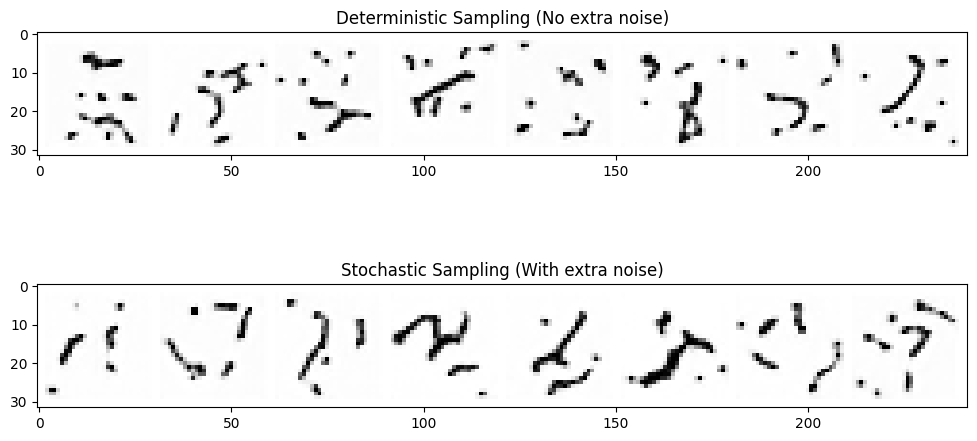

In [24]:
def custom_sample(stochastic=True, n_steps=40):
    x = torch.randn(8, 1, 28, 28).to(device)
    for i in range(n_steps):
        with torch.no_grad():
            pred = net(x, 0).sample

        mix_factor = 1 / (n_steps - i)
        x = x * (1 - mix_factor) + pred * mix_factor

        # Nếu là Stochastic, thêm một lượng nhỏ nhiễu ngẫu nhiên để tạo sự đa dạng
        if stochastic and i < n_steps - 1:
            noise = torch.randn_like(x) * 0.05
            x += noise
    return x

deterministic_x = custom_sample(stochastic=False)
stochastic_x = custom_sample(stochastic=True)

fig, axs = plt.subplots(2, 1, figsize=(12, 6))
axs[0].imshow(torchvision.utils.make_grid(deterministic_x.cpu())[0].clip(0, 1), cmap='Greys')
axs[0].set_title('Deterministic Sampling (No extra noise)')
axs[1].imshow(torchvision.utils.make_grid(stochastic_x.cpu())[0].clip(0, 1), cmap='Greys')
axs[1].set_title('Stochastic Sampling (With extra noise)')
plt.show()

This looks quite a bit better than our first set of results! You can explore tweaking the unet configuration or training for longer to get even better performance.

## Conclusions

Hopefully this has been a helpful way to look at diffusion models from a slightly different angle.

This notebook was written for this Hugging Face course by Jonathan Whitaker, and overlaps with a [version included in his own course](https://johnowhitaker.github.io/tglcourse/dm1.html), 'The Generative Landscape'. Check that out if you'd like to see this basic example extended with noise and class conditioning. Questions or bugs can be communicated through GitHub issues or via Discord. You are also welcome to reach out via Twitter [@johnowhitaker](https://twitter.com/johnowhitaker).